#**PRAKTIKUM MANDIRI PERTEMUAN 11 (Explore Algoritma Clustering lain – DBSCAN)**

###**Hubungkan ke google drive untuk mengambil dataset**

In [ ]:
# menghubungkan colab dengan google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###**1. Import library yang dibutuhkan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

###**2. Load Dataset dari Google Drive**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Semester_7/praktikum_ml/praktikum11/data/Iris.csv')

# Lihat beberapa baris
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


###**3. Pre-Processing Data**

In [ ]:
# Hapus kolom id karena tidak diperlukan dalam clustering
df = df.drop(columns=['Id'])

In [ ]:
# Encode kolom kategori species
le = LabelEncoder()
df['SpeciesEncoded'] = le.fit_transform(df['Species'])

In [ ]:
# Tentukan fitur (X)
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

In [ ]:
# Scaling Fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

###**4. DBSCAN Clustering**

In [ ]:
dbscan = DBSCAN(eps=0.6, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

# Tambahkan cluster ke dataframe
df['Cluster'] = clusters
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,SpeciesEncoded,Cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,0,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0,0


###**5. Cek Hasil Cluster**

In [ ]:
df['Cluster'].value_counts()

,count
Cluster,
1,78
0,46
-1,26


###**6. Hitung Silhouette Score**

In [ ]:
mask = df['Cluster'] != -1  # hapus noise
sil_score = silhouette_score(X_scaled[mask], df['Cluster'][mask])
print("Silhouette Score:", sil_score)

Silhouette Score: 0.6405002985705055


###**7. Visualisasi Hasil Clustering**

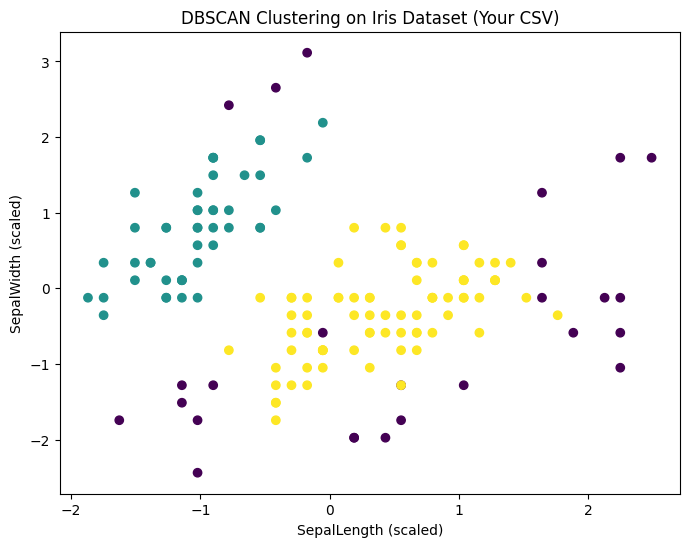

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'], cmap='viridis')
plt.title("DBSCAN Clustering on Iris Dataset (Your CSV)")
plt.xlabel("SepalLength (scaled)")
plt.ylabel("SepalWidth (scaled)")
plt.show()

####**Visualisasi 3D**

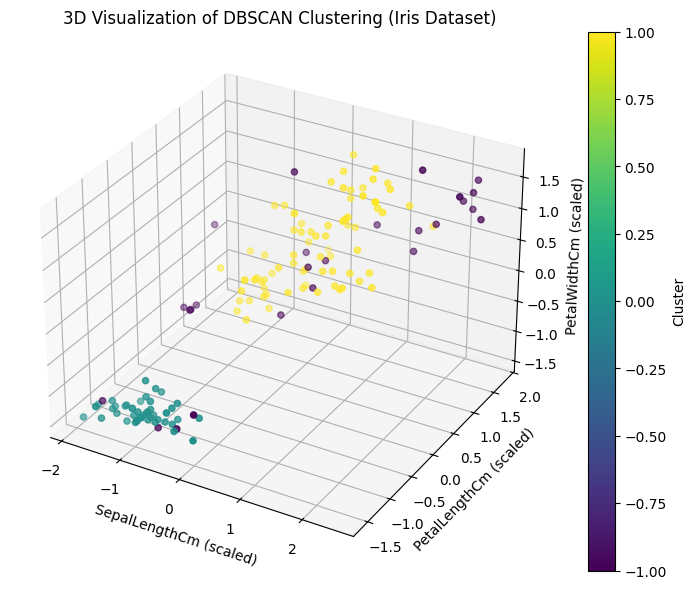

In [ ]:
x = X_scaled[:, 0]   # SepalLength
y = X_scaled[:, 2]   # PetalLength
z = X_scaled[:, 3]   # PetalWidth

clusters = df['Cluster']

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, c=clusters, cmap='viridis')

ax.set_xlabel("SepalLengthCm (scaled)")
ax.set_ylabel("PetalLengthCm (scaled)")
ax.set_zlabel("PetalWidthCm (scaled)")
ax.set_title("3D Visualization of DBSCAN Clustering (Iris Dataset)")

plt.colorbar(scatter, label="Cluster")
plt.show()